In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Environment working correctly")


Environment working correctly


In [2]:
import pandas as pd
import random
from datetime import datetime, timedelta

airlines = ["JetBlue", "Delta", "American", "Spirit", "United"]
destinations = ["MIA", "MCO", "TPA", "FLL"]

data = []

for i in range(200):

    airline = random.choice(airlines)
    destination = random.choice(destinations)

    departure_date = datetime.today() + timedelta(days=random.randint(1,30))

    price = random.randint(90, 400)
    stops = random.choice([0,1])

    data.append({
        "search_date": datetime.today().date(),
        "origin": "BOS",
        "destination": destination,
        "airline": airline,
        "price": price,
        "stops": stops,
        "departure_date": departure_date.date()
    })

df = pd.DataFrame(data)

df.head()


,search_date,origin,destination,airline,price,stops,departure_date
0,2026-03-11,BOS,FLL,Spirit,102,0,2026-03-19
1,2026-03-11,BOS,MIA,United,191,0,2026-03-20
2,2026-03-11,BOS,FLL,United,148,1,2026-03-17
3,2026-03-11,BOS,MCO,United,181,0,2026-03-27
4,2026-03-11,BOS,MIA,United,270,0,2026-04-02


In [5]:
df.to_csv("flights_raw.csv", index=False)


In [6]:
import pandas as pd

df = pd.read_csv("data/raw/flights_raw.csv")

df.head()


,search_date,origin,destination,airline,price,stops,departure_date
0,2026-03-11,BOS,FLL,Spirit,102,0,2026-03-19
1,2026-03-11,BOS,MIA,United,191,0,2026-03-20
2,2026-03-11,BOS,FLL,United,148,1,2026-03-17
3,2026-03-11,BOS,MCO,United,181,0,2026-03-27
4,2026-03-11,BOS,MIA,United,270,0,2026-04-02


In [7]:
df.shape


(200, 7)

In [8]:
df["airline"].value_counts()


airline
JetBlue     48
Spirit      43
American    41
United      40
Delta       28
Name: count, dtype: int64

In [9]:
df.groupby("airline")["price"].mean()


airline
American    235.121951
Delta       230.428571
JetBlue     260.083333
Spirit      244.767442
United      262.900000
Name: price, dtype: float64

In [10]:
df.groupby("airline")["price"].mean().sort_values()


airline
Delta       230.428571
American    235.121951
Spirit      244.767442
JetBlue     260.083333
United      262.900000
Name: price, dtype: float64

C:\Users\gravi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Verdana.
  fig.canvas.print_figure(bytes_io, **kw)


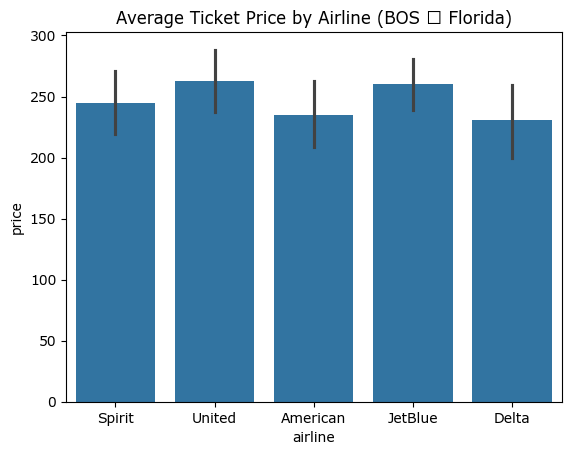

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=df, x="airline", y="price")

plt.title("Average Ticket Price by Airline (BOS → Florida)")
plt.show()


In [12]:
df_clean = df.copy()

df_clean["route"] = df_clean["origin"] + "-" + df_clean["destination"]

df_clean.head()


,search_date,origin,destination,airline,price,stops,departure_date,route
0,2026-03-11,BOS,FLL,Spirit,102,0,2026-03-19,BOS-FLL
1,2026-03-11,BOS,MIA,United,191,0,2026-03-20,BOS-MIA
2,2026-03-11,BOS,FLL,United,148,1,2026-03-17,BOS-FLL
3,2026-03-11,BOS,MCO,United,181,0,2026-03-27,BOS-MCO
4,2026-03-11,BOS,MIA,United,270,0,2026-04-02,BOS-MIA


In [13]:
df_clean.to_csv("data/processed/flights_final.csv", index=False)
